############################################################################
# STEP 0: ESSENTIAL LIBRARIES AND FUNCTIONS
############################################################################

In [1]:
import numpy as np
import pandas as pd
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import warnings
warnings.simplefilter(action="ignore")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_rows', 20)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

/kaggle/input/irelandhousepriceprediction/CA1_national_house_construction_cost_index.csv
/kaggle/input/irelandhousepriceprediction/CA1_dataset.xlsx
/kaggle/input/irelandhousepriceprediction/CA1_ireland_new_house_price.csv


In [2]:
# IMPORT AND READ DATASETS
OtherDatasets = pd.read_excel("/kaggle/input/irelandhousepriceprediction/CA1_dataset.xlsx")
NewHousePrice = pd.read_csv("/kaggle/input/irelandhousepriceprediction/CA1_ireland_new_house_price.csv")
NationalHouseConstructionCostIndex = pd.read_csv("/kaggle/input/irelandhousepriceprediction/CA1_national_house_construction_cost_index.csv")

CombineDataset = pd.merge(NationalHouseConstructionCostIndex,NewHousePrice, how="right", on="Year")
# CombineDataset

housing = pd.merge(CombineDataset,OtherDatasets, how="right", on="Year")
# housing

df = housing.rename(columns={"Yearly average": "NationalHouseConstructionCostIndex100Base1991", "% Increase on previous year": "NationalHouseConstructionCostIndexIncreaseonPreviousYearRate", "Dublin Value": "DublinNewHousePrice€", "National Value": "NationalNewHousePrice€"})
#df.head(20)
#df.tail(20)
df

,Year,NationalHouseConstructionCostIndex100Base1991,NationalHouseConstructionCostIndexIncreaseonPreviousYearRate,DublinNewHousePrice€,NationalNewHousePrice€,IEPopulation,DublinPopulation,IEUrbanPopulation,IEMigrantPopulation,IEInflationRate,IEInflationAnnualChangeRate,IEGDP$B,IEGDPPerCapita$,IEGDPGrowthRate,IEUnemploymentRate,IEUnemploymentRateAnnualChangeRate,IERefugeesGrantedAsylum,IERefugeesGrantedAsylumAnnualChangeRate
0,2016,NaN,NaN,397676,313483,4715788,1176000,2983355,NaN,0.000,0.003,299.090,62896,0.020,0.084,-0.015,5720.000,-0.064
1,2015,207.100,0.005,377741,281432,4665760,1163000,2940510,746260.000,-0.003,-0.005,291.780,62054,0.244,0.099,-0.019,6108.000,0.047
2,2014,206.000,0.006,333720,246378,4622167,1150000,2903635,738401.000,0.002,-0.003,259.170,55643,0.086,0.119,-0.019,5832.000,-0.026
3,2013,204.700,0.006,300466,228216,4588832,1138000,2873286,738401.000,0.005,-0.012,238.340,51546,0.011,0.137,-0.017,5991.000,-0.050
4,2012,203.500,0.002,265633,220415,4564550,1126000,2849043,738401.000,0.017,-0.009,225.630,49055,-0.000,0.154,0.001,6309.000,-0.234
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37,1979,NaN,NaN,32005,29387,3351898,889000,1855360,197334.000,0.133,0.056,18.320,5430,0.031,NaN,NaN,NaN,NaN
38,1978,NaN,NaN,25745,24082,3305571,875000,1819520,197334.000,0.077,-0.058,14.650,4400,0.072,NaN,NaN,NaN,NaN
39,1977,NaN,NaN,19055,18754,3254662,861000,1782727,197334.000,0.135,-0.045,11.250,3427,0.082,NaN,NaN,NaN,NaN
40,1976,NaN,NaN,15342,15564,3205753,847000,1747737,197334.000,0.180,-0.029,9.450,2920,0.014,NaN,NaN,NaN,NaN


#######################################################################
# STEP 1: EXPLORATORY DATA ANALYSIS (EDA)
#######################################################################

In [3]:
###########################
# GENERAL REVIEW TO DATASET
###########################
'''
!pip install skimpy
from skimpy import skim
skim(df)
'''

def check_df(dataframe, head=5):
    print("##################### Shape #####################")
    print(dataframe.shape)
    print("##################### Types #####################")
    print(dataframe.dtypes)
    print("##################### Head #####################")
    print(dataframe.head(head))
    print("##################### Tail #####################")
    print(dataframe.tail(head))
    print("##################### NA #####################")
    print(dataframe.isnull().sum())
    print("##################### Quantiles #####################")
    print(dataframe.quantile([0, 0.05, 0.50, 0.95, 0.99, 1]).T)
check_df(df)

#df.head()
#df.info()
#df.describe()

##################### Shape #####################
(42, 18)
##################### Types #####################
Year                                                              int64
NationalHouseConstructionCostIndex100Base1991                   float64
NationalHouseConstructionCostIndexIncreaseonPreviousYearRate    float64
DublinNewHousePrice€                                              int64
NationalNewHousePrice€                                            int64
IEPopulation                                                      int64
DublinPopulation                                                  int64
IEUrbanPopulation                                                 int64
IEMigrantPopulation                                             float64
IEInflationRate                                                 float64
IEInflationAnnualChangeRate                                     float64
IEGDP$B                                                         float64
IEGDPPerCapita$            

In [4]:
#############################################
# CAPTURING NUMERIC AND CATEGORICAL VARIABLES
#############################################

def grab_col_names(dataframe, cat_th=10, car_th=20):
    
    """
    Gives the names of categorical, numeric and categorical but cardinal variables in the dataset.
    Note: Categorical variables with numerical appearance are also included in the categorical variables.

    Parameters
    ------
        dataframe: dataframe
                Değişken isimleri alınmak istenilen dataframe
        cat_th: int, optional
                numerik fakat kategorik olan değişkenler için sınıf eşik değeri
        car_th: int, optional
                kategorik fakat kardinal değişkenler için sınıf eşik değeri

    Returns
    ------
        cat_cols: list
                Kategorik değişken listesi
        num_cols: list
                Numerik değişken listesi
        cat_but_car: list
                Kategorik görünümlü kardinal değişken listesi

    Examples
    ------
        import seaborn as sns
        df = sns.load_dataset("iris")
        print(grab_col_names(df))


    Notes
    ------
        cat_cols + num_cols + cat_but_car = toplam değişken sayısı
        num_but_cat cat_cols'un içerisinde.
    """
    
    # cat_cols, cat_but_car
    cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"]
    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and dataframe[col].dtypes != "O"]
    cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and dataframe[col].dtypes == "O"]
    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    # num_cols
    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != "O"]
    num_cols = [col for col in num_cols if col not in num_but_cat]

    print(f"Observations: {dataframe.shape[0]}")
    print(f"Variables: {dataframe.shape[1]}")
    print(f'cat_cols: {len(cat_cols)}')
    print(f'num_cols: {len(num_cols)}')
    print(f'cat_but_car: {len(cat_but_car)}')
    print(f'num_but_cat: {len(num_but_cat)}')

    return cat_cols, num_cols, cat_but_car


cat_cols, num_cols, cat_but_car = grab_col_names(df)

num_cols
# cat_cols
# cat_but_car

Observations: 42
Variables: 18
cat_cols: 0
num_cols: 18
cat_but_car: 0
num_but_cat: 0


['Year',
 'NationalHouseConstructionCostIndex100Base1991',
 'NationalHouseConstructionCostIndexIncreaseonPreviousYearRate',
 'DublinNewHousePrice€',
 'NationalNewHousePrice€',
 'IEPopulation',
 'DublinPopulation',
 'IEUrbanPopulation',
 'IEMigrantPopulation',
 'IEInflationRate',
 'IEInflationAnnualChangeRate',
 'IEGDP$B',
 'IEGDPPerCapita$',
 'IEGDPGrowthRate',
 'IEUnemploymentRate',
 'IEUnemploymentRateAnnualChangeRate',
 'IERefugeesGrantedAsylum',
 'IERefugeesGrantedAsylumAnnualChangeRate']

count     42.000
mean    1995.500
std       12.268
min     1975.000
5%      1977.050
10%     1979.100
20%     1983.200
30%     1987.300
40%     1991.400
50%     1995.500
60%     1999.600
70%     2003.700
80%     2007.800
90%     2011.900
95%     2013.950
99%     2015.590
max     2016.000
Name: Year, dtype: float64


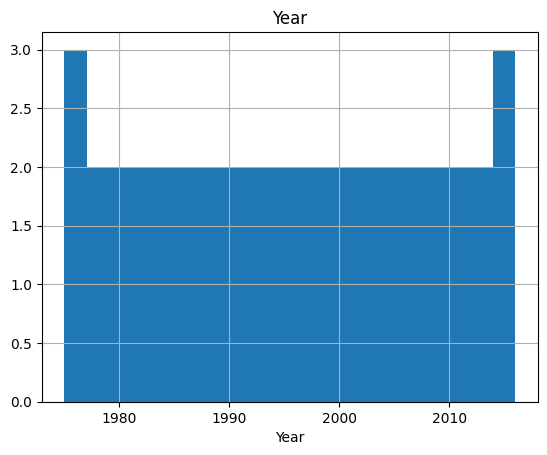

count    22.000
mean    171.927
std      37.033
min     111.000
5%      114.780
10%     116.710
20%     126.120
30%     147.150
40%     173.680
50%     184.200
60%     198.700
70%     203.380
80%     205.740
90%     207.040
95%     208.620
99%     209.253
max     209.400
Name: NationalHouseConstructionCostIndex100Base1991, dtype: float64


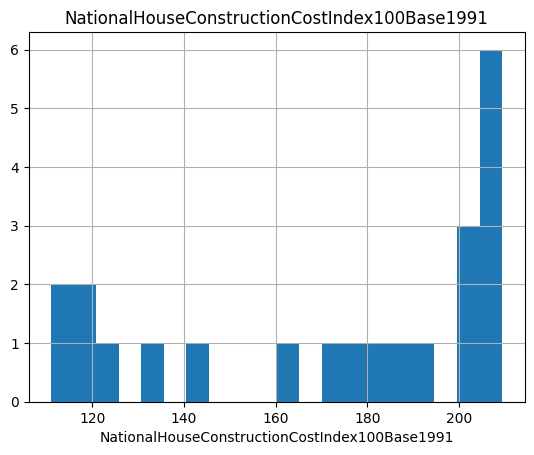

count   22.000
mean     0.031
std      0.035
min     -0.027
5%      -0.013
10%      0.002
20%      0.006
30%      0.012
40%      0.027
50%      0.032
60%      0.035
70%      0.038
80%      0.039
90%      0.063
95%      0.075
99%      0.131
max      0.145
Name: NationalHouseConstructionCostIndexIncreaseonPreviousYearRate, dtype: float64


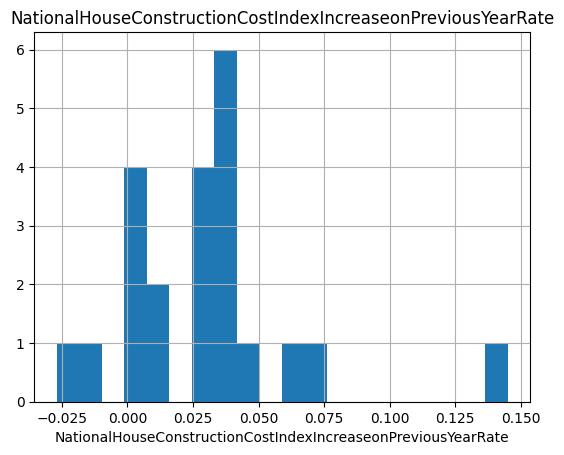

count       42.000
mean    167223.881
std     133489.765
min      13137.000
5%       19389.500
10%      32586.700
20%      48832.400
30%      53021.900
40%      78909.000
50%      91864.500
60%     210444.800
70%     258951.700
80%     298702.000
90%     368534.600
95%     396679.250
99%     412015.120
max     416225.000
Name: DublinNewHousePrice€, dtype: float64


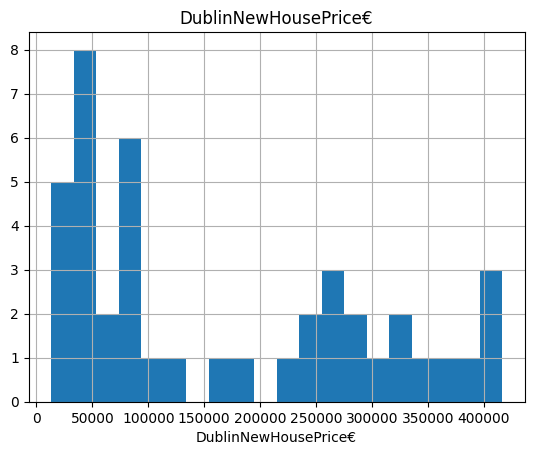

count       42.000
mean    135081.952
std     102007.924
min      13254.000
5%       19020.400
10%      29945.000
20%      44642.200
30%      49514.200
40%      67854.000
50%      82598.000
60%     160923.000
70%     223321.400
80%     239687.000
90%     280910.900
95%     305618.600
99%     318882.090
max     322634.000
Name: NationalNewHousePrice€, dtype: float64


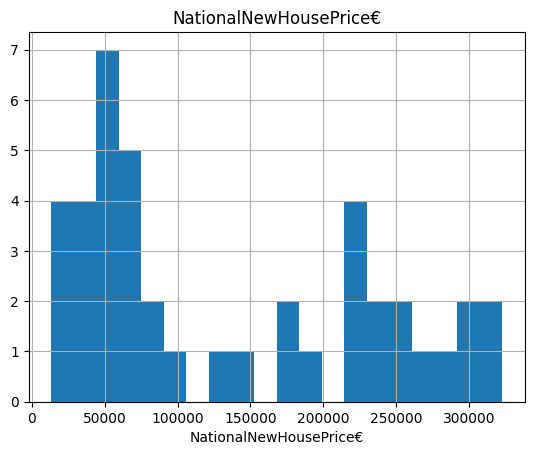

count        42.000
mean    3815458.000
std      474902.300
min     3157919.000
5%      3257207.450
10%     3355846.900
20%     3474985.200
30%     3500062.500
40%     3520748.200
50%     3593105.000
60%     3749334.800
70%     4009979.300
80%     4433880.400
90%     4562545.100
95%     4620500.250
99%     4695276.520
max     4715788.000
Name: IEPopulation, dtype: float64


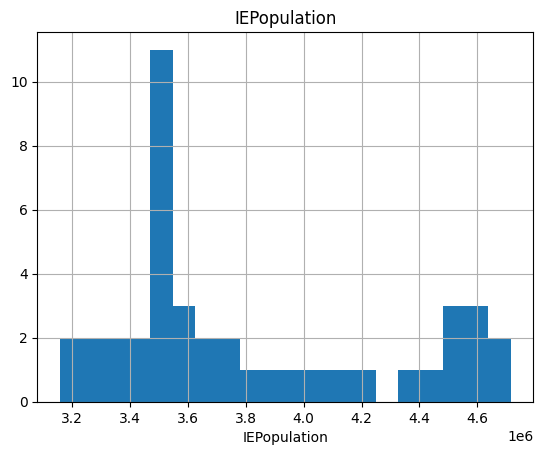

count        42.000
mean     981547.619
std       92212.428
min      833000.000
5%       861700.000
10%      890400.000
20%      917000.000
30%      919000.000
40%      922200.000
50%      950000.000
60%      985400.000
70%     1024000.000
80%     1071400.000
90%     1124700.000
95%     1149400.000
99%     1170670.000
max     1176000.000
Name: DublinPopulation, dtype: float64


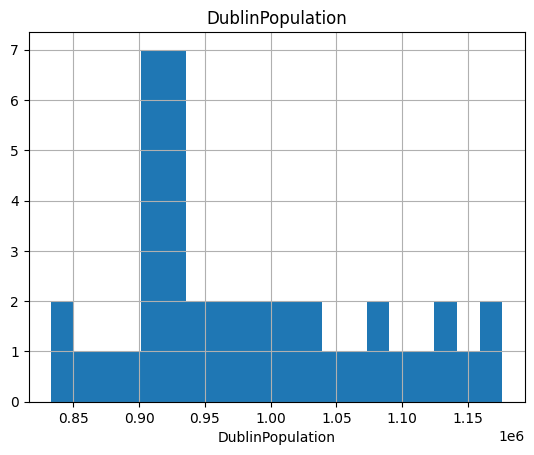

count        42.000
mean    2256442.262
std      382758.950
min     1710683.000
5%      1784566.650
10%     1858664.500
20%     1967928.600
30%     1997500.000
40%     2025748.800
50%     2103668.000
60%     2235348.200
70%     2433739.800
80%     2732104.600
90%     2846922.200
95%     2902117.550
99%     2965788.550
max     2983355.000
Name: IEUrbanPopulation, dtype: float64


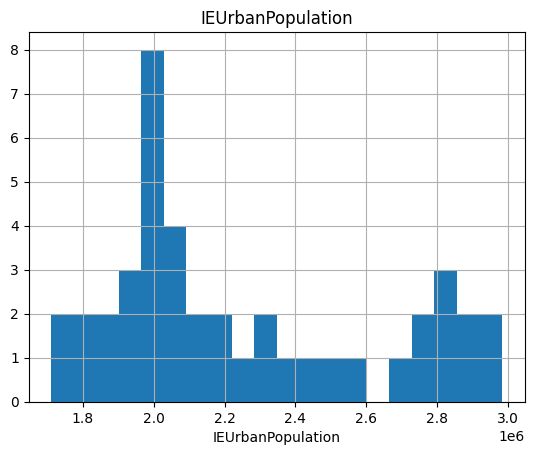

count       41.000
mean    380991.537
std     209185.734
min     171429.000
5%      197334.000
10%     197334.000
20%     224262.000
30%     226623.000
40%     227427.000
50%     227961.000
60%     288722.000
70%     469799.000
80%     659794.000
90%     738401.000
95%     738401.000
99%     743116.400
max     746260.000
Name: IEMigrantPopulation, dtype: float64


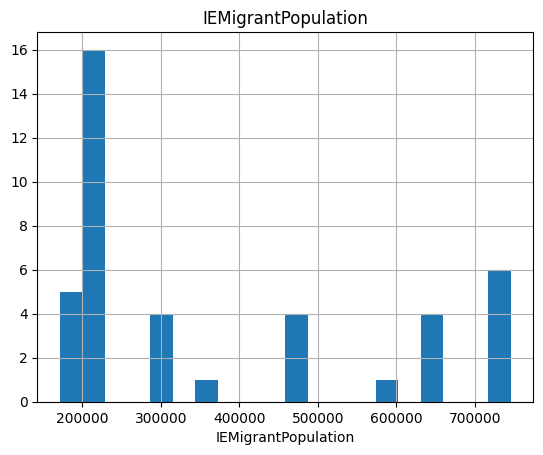

count   42.000
mean     0.054
std      0.061
min     -0.045
5%      -0.003
10%      0.002
20%      0.016
30%      0.022
40%      0.025
50%      0.033
60%      0.040
70%      0.049
80%      0.085
90%      0.168
95%      0.181
99%      0.207
max      0.209
Name: IEInflationRate, dtype: float64


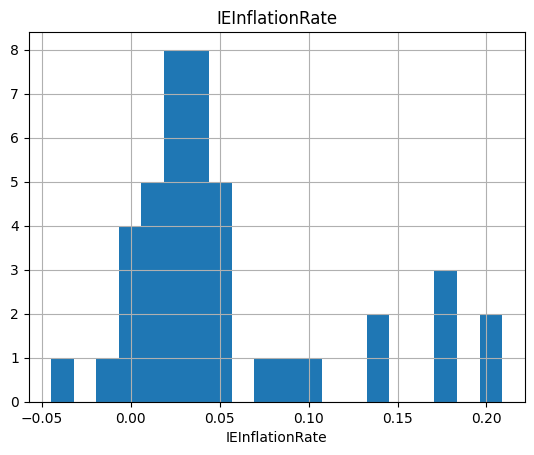

count   42.000
mean    -0.004
std      0.029
min     -0.085
5%      -0.057
10%     -0.033
20%     -0.016
30%     -0.011
40%     -0.008
50%     -0.006
60%     -0.002
70%      0.003
80%      0.014
90%      0.036
95%      0.040
99%      0.053
max      0.056
Name: IEInflationAnnualChangeRate, dtype: float64


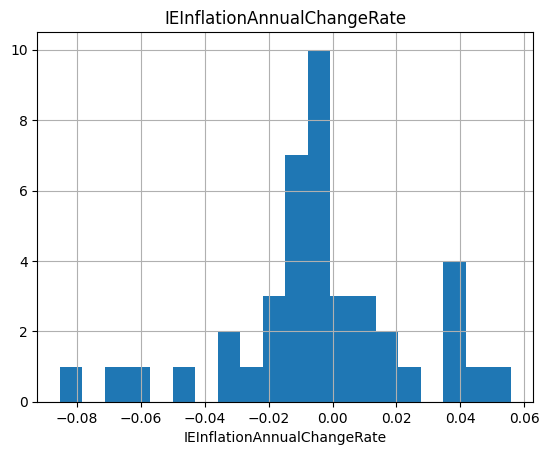

count    42.000
mean    112.105
std      97.875
min       9.450
5%       11.420
10%      18.499
20%      21.310
30%      35.075
40%      50.842
50%      72.465
60%      99.682
70%     185.460
80%     230.870
90%     257.153
95%     275.181
99%     296.093
max     299.090
Name: IEGDP$B, dtype: float64


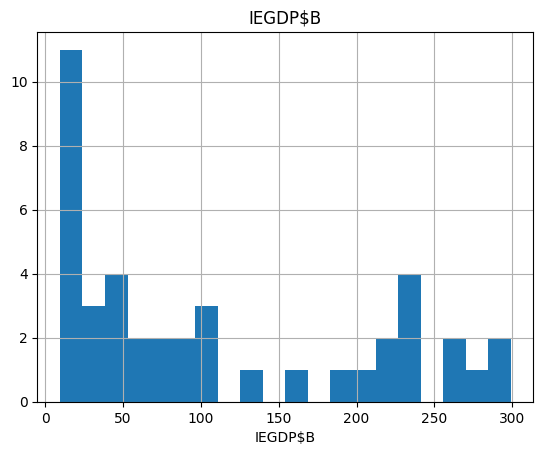

count      42.000
mean    26688.310
std     20881.566
min      2920.000
5%       3475.650
10%      5456.200
20%      6041.800
30%      9922.200
40%     14315.000
50%     19997.000
60%     26336.800
70%     45789.000
80%     51423.400
90%     55511.600
95%     61393.850
99%     62550.780
max     62896.000
Name: IEGDPPerCapita$, dtype: float64


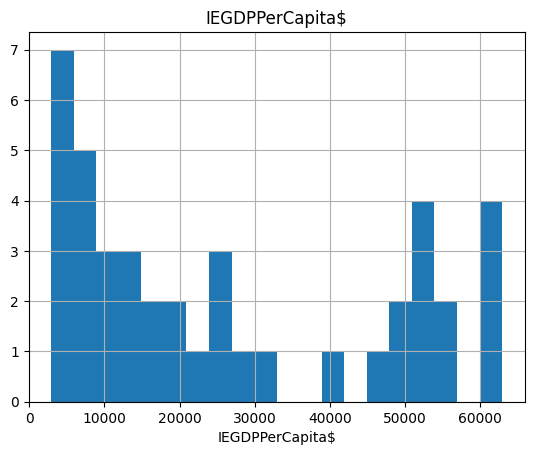

count   42.000
mean     0.048
std      0.048
min     -0.051
5%      -0.004
10%      0.001
20%      0.017
30%      0.028
40%      0.032
50%      0.048
60%      0.055
70%      0.059
80%      0.080
90%      0.093
95%      0.105
99%      0.189
max      0.244
Name: IEGDPGrowthRate, dtype: float64


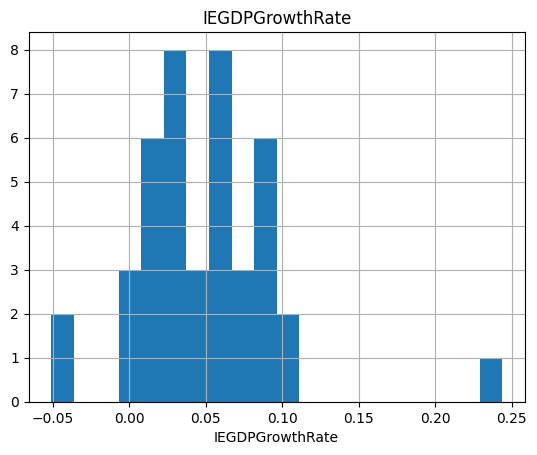

count   26.000
mean     0.097
std      0.045
min      0.037
5%       0.042
10%      0.043
20%      0.045
30%      0.054
40%      0.077
50%      0.101
60%      0.119
70%      0.132
80%      0.146
90%      0.154
95%      0.156
99%      0.157
max      0.158
Name: IEUnemploymentRate, dtype: float64


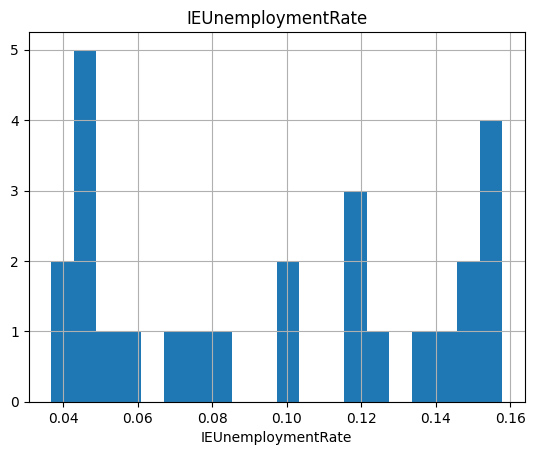

count   26.000
mean    -0.003
std      0.017
min     -0.026
5%      -0.024
10%     -0.019
20%     -0.017
30%     -0.015
40%     -0.007
50%     -0.005
60%      0.000
70%      0.002
80%      0.006
90%      0.013
95%      0.019
99%      0.049
max      0.058
Name: IEUnemploymentRateAnnualChangeRate, dtype: float64


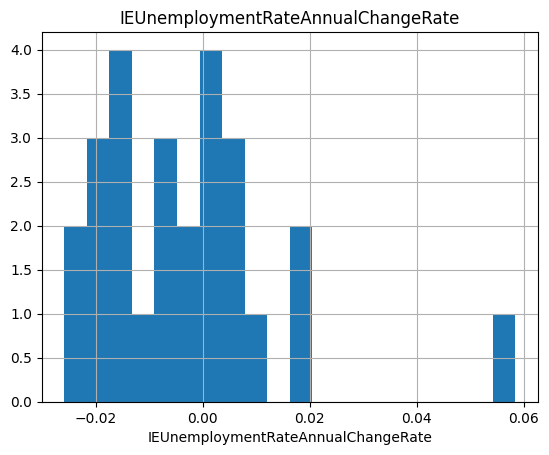

count     33.000
mean    3758.242
std     3478.106
min       69.000
5%       227.600
10%      368.000
20%      424.000
30%      500.000
40%      600.000
50%     2829.000
60%     5742.400
70%     6037.800
80%     6873.800
90%     8926.000
95%     9415.200
99%     9665.040
max     9714.000
Name: IERefugeesGrantedAsylum, dtype: float64


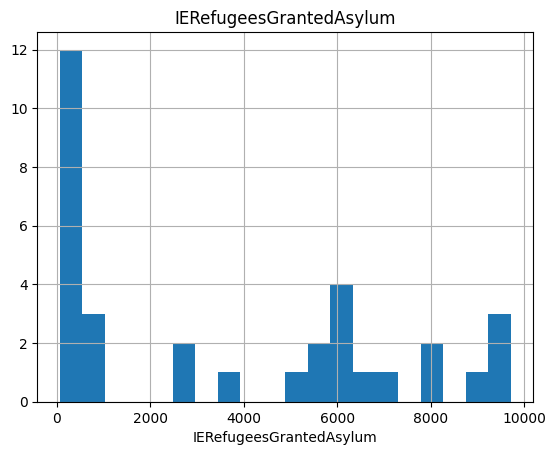

count   33.000
mean     0.348
std      1.191
min     -0.828
5%      -0.445
10%     -0.162
20%     -0.109
30%     -0.076
40%     -0.031
50%      0.000
60%      0.089
70%      0.139
80%      0.317
90%      0.633
95%      2.903
99%      4.746
max      5.232
Name: IERefugeesGrantedAsylumAnnualChangeRate, dtype: float64


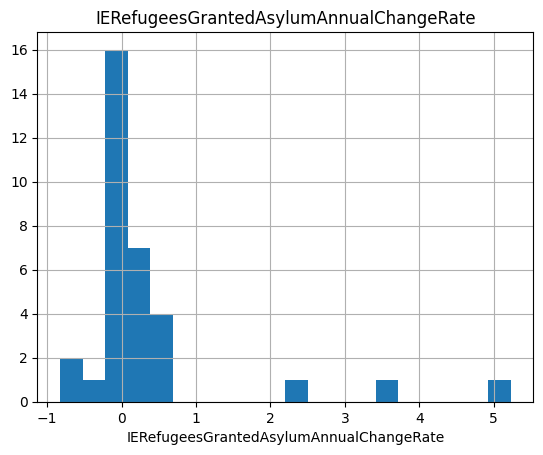

'\ndef target_summary_with_num(df, target, numerical_col):\n    print(df.groupby(target).agg({numerical_col: "mean"}), end="\n\n\n")\n\nfor col in num_cols:\n    target_summary_with_num(df, "Outcome", col)\n\n#################\n🎯 Ne İşe Yarar?\n- Hedef değişkene göre değişkenlerin dağılımını görmek için çok faydalı.\n- Özellikle makine öğrenmesi modelleme sürecinde, değişkenler hedefi ne kadar ayırıyor? sorusuna cevap ararken kullanılır.\n- Hedef değişken ile güçlü ilişkili olan sayısal değişkenleri hızlıca ayırt etmeyi sağlar.\n#################\n'

In [5]:
#################################
# ANALYSIS OF NUMERICAL VARIABLES
#################################
import matplotlib.pyplot as plt

def num_summary(dataframe, numerical_col, plot=False):
    quantiles = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
    print(dataframe[numerical_col].describe(quantiles).T)

    if plot:
        dataframe[numerical_col].hist(bins=20)
        plt.xlabel(numerical_col)
        plt.title(numerical_col)
        plt.show()

for col in num_cols:
    num_summary(df, col, plot=True)

###########################################
# ANALYSIS OF NUMERICAL VARIABLES BY TARGET
###########################################
'''
def target_summary_with_num(df, target, numerical_col):
    print(df.groupby(target).agg({numerical_col: "mean"}), end="\n\n\n")

for col in num_cols:
    target_summary_with_num(df, "Outcome", col)

#################
🎯 Ne İşe Yarar?
- Hedef değişkene göre değişkenlerin dağılımını görmek için çok faydalı.
- Özellikle makine öğrenmesi modelleme sürecinde, değişkenler hedefi ne kadar ayırıyor? sorusuna cevap ararken kullanılır.
- Hedef değişken ile güçlü ilişkili olan sayısal değişkenleri hızlıca ayırt etmeyi sağlar.
#################
'''

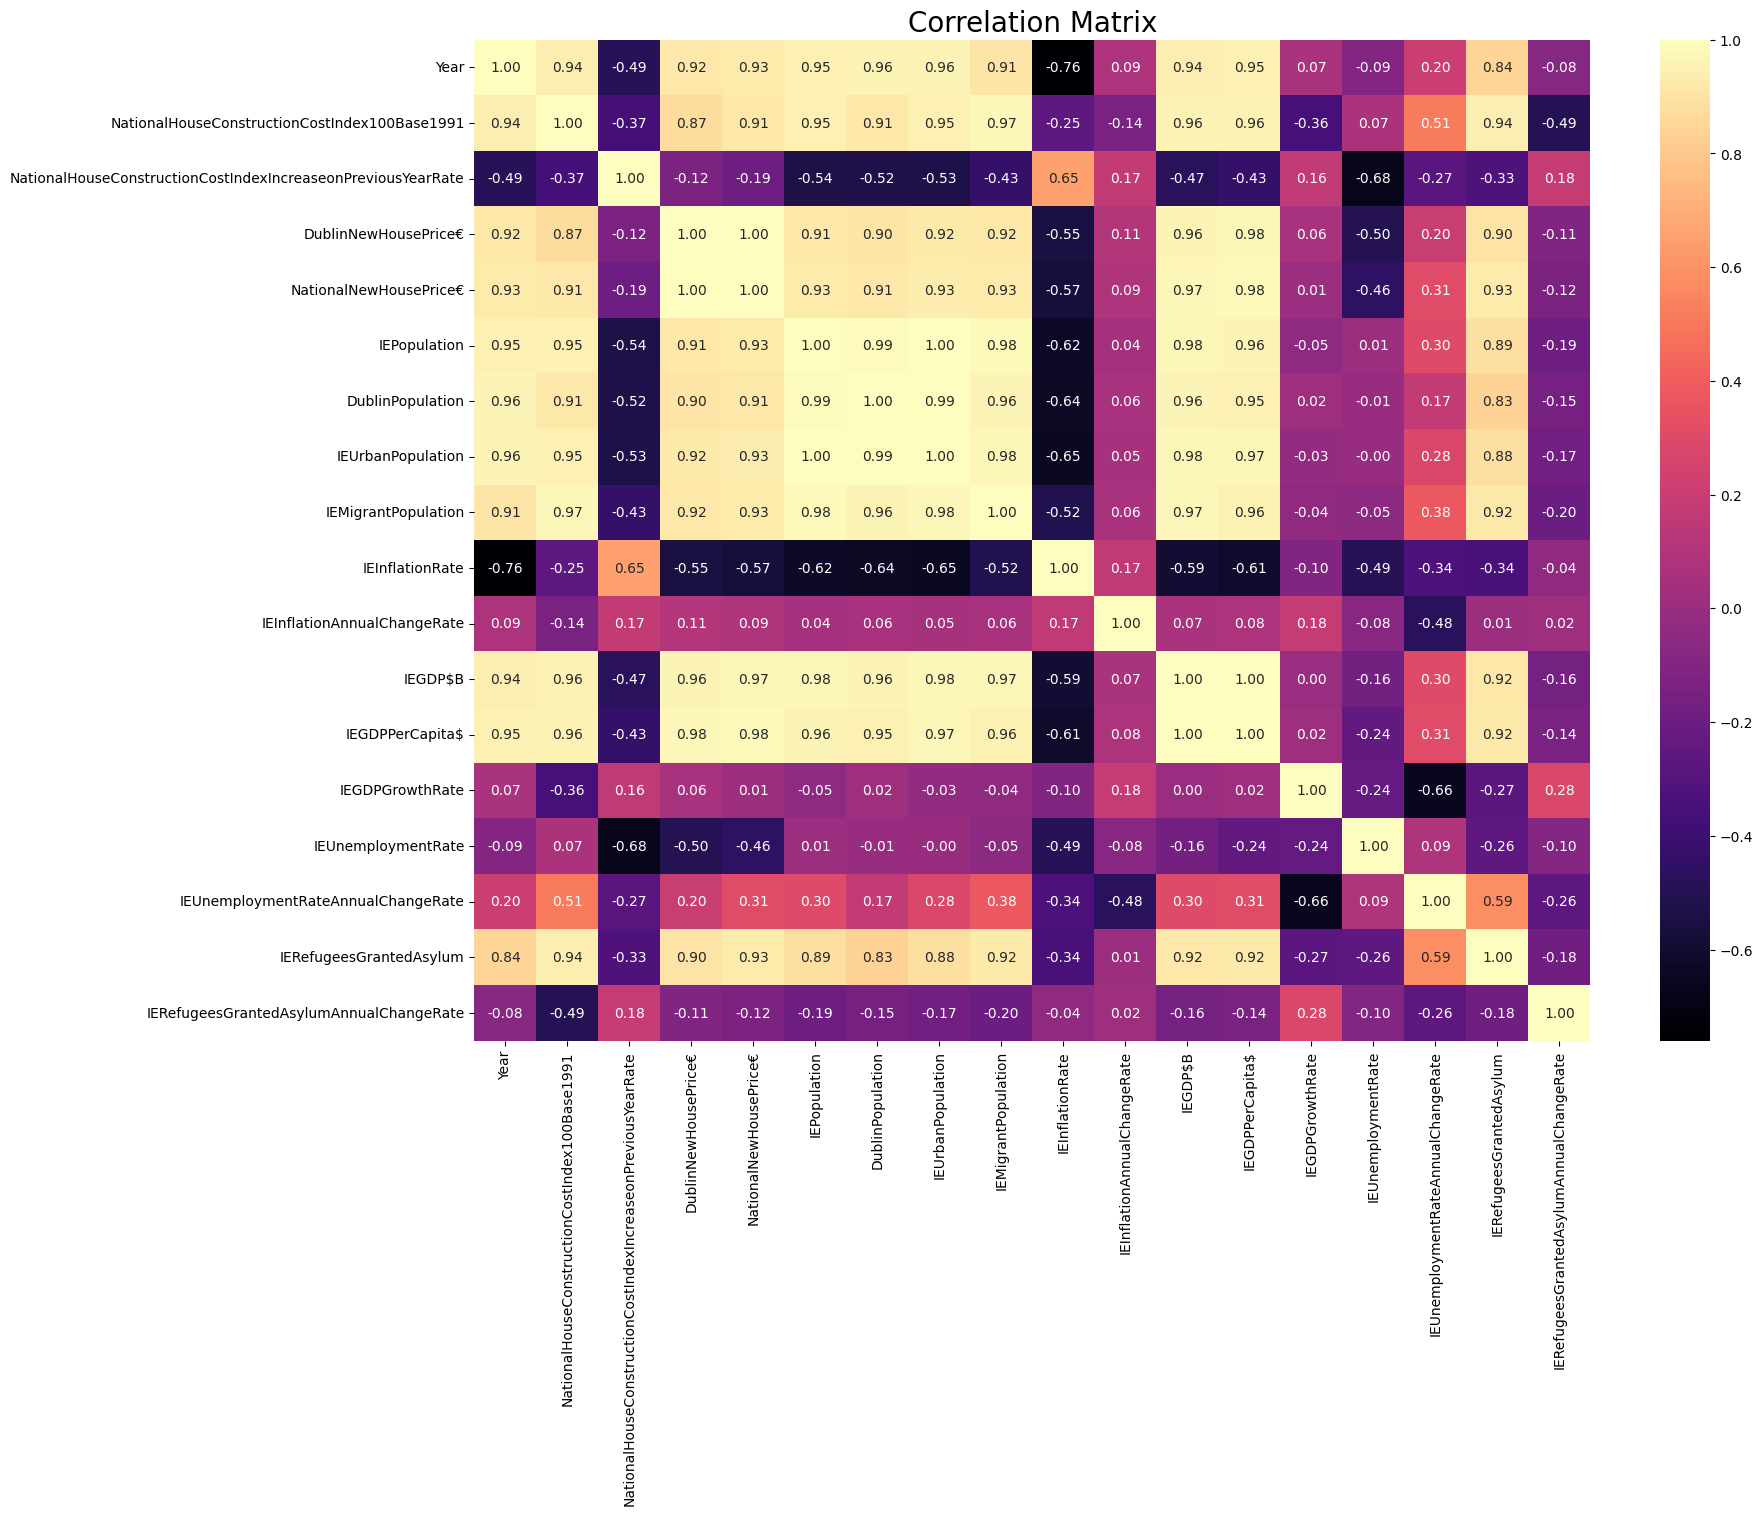

In [6]:
##############
# CORRELATION
##############
import seaborn as sns
# Korelasyon, olasılık kuramı ve istatistikte iki rassal değişken arasındaki doğrusal ilişkinin yönünü ve gücünü belirtir.
df.corr()

####################
# CORRELATION MATRIX
####################
f, ax = plt.subplots(figsize=[18, 13])
sns.heatmap(df.corr(), annot=True, fmt=".2f", ax=ax, cmap="magma")
ax.set_title("Correlation Matrix", fontsize=20)
plt.show()

###################################################
# STEP 2: DATA PRE-PROCESSING (MISSING VALUES AND OUTLIERS)
###################################################

In [7]:
#########################
# MISSING VALUE ANALYSIS
#########################

# Determine which columns have 0 values.
zero_columns = [col for col in df.columns if (df[col].min() == 0)]
zero_columns

# Values that are 0 can be assigned NaN.
for col in zero_columns:
    df[col] = np.where(df[col] == 0, np.nan, df[col])

# Missing Value Analysis
df.isnull().sum()

Year                                                             0
NationalHouseConstructionCostIndex100Base1991                   20
NationalHouseConstructionCostIndexIncreaseonPreviousYearRate    20
DublinNewHousePrice€                                             0
NationalNewHousePrice€                                           0
IEPopulation                                                     0
DublinPopulation                                                 0
IEUrbanPopulation                                                0
IEMigrantPopulation                                              1
IEInflationRate                                                  0
IEInflationAnnualChangeRate                                      0
IEGDP$B                                                          0
IEGDPPerCapita$                                                  0
IEGDPGrowthRate                                                  0
IEUnemploymentRate                                            

In [8]:
######################################################
# Number of Missing Observations and Percentage(Ratio)
def missing_values_table(dataframe, na_name=False):
    na_columns = [col for col in dataframe.columns if dataframe[col].isnull().sum() > 0]
    n_miss = dataframe[na_columns].isnull().sum().sort_values(ascending=False)
    ratio = (dataframe[na_columns].isnull().sum() / dataframe.shape[0] * 100).sort_values(ascending=False)
    missing_df = pd.concat([n_miss, np.round(ratio, 2)], axis=1, keys=['n_miss', 'ratio'])
    print(missing_df, end="\n")
    if na_name:
        return na_columns
na_columns = missing_values_table(df, na_name=True)

#################
'''
🎯 What is it used for?
- It is used to detect missing data, to decide which variables should be filled, deleted or excluded from analysis.
- It is used especially before data cleaning and missing data imputation processes.
'''
#################

##########################################################################
# Examining the Relationship of Missing Values with the Dependent Variable
def missing_vs_target(df, target, na_columns):
    temp_df = df.copy()
    for col in na_columns:
        temp_df[col + '_NA_FLAG'] = np.where(temp_df[col].isnull(), 1, 0)
    na_flags = temp_df.loc[:, temp_df.columns.str.contains("_NA_")].columns
    for col in na_flags:
        print(pd.DataFrame({"TARGET_MEAN": temp_df.groupby(col)[target].mean(),
                            "Count": temp_df.groupby(col)[target].count()}), end="\n\n\n")

missing_vs_target(df, "DublinNewHousePrice€", na_columns)

###########################
# Filling in Missing Values
for col in zero_columns:
    df.loc[df[col].isnull(), col] = df[col].median()

df.isnull().sum()

                                                    n_miss  ratio
NationalHouseConstructionCostIndex100Base1991           20 47.620
NationalHouseConstructionCostIndexIncreaseonPre...      20 47.620
IEUnemploymentRate                                      16 38.100
IEUnemploymentRateAnnualChangeRate                      16 38.100
IERefugeesGrantedAsylum                                  9 21.430
IERefugeesGrantedAsylumAnnualChangeRate                  9 21.430
IEMigrantPopulation                                      1  2.380
                                                    TARGET_MEAN  Count
NationalHouseConstructionCostIndex100Base1991_N...                    
0                                                    259126.364     22
1                                                     66131.150     20


                                                    TARGET_MEAN  Count
NationalHouseConstructionCostIndexIncreaseonPre...                    
0                                           

Year                                                             0
NationalHouseConstructionCostIndex100Base1991                   20
NationalHouseConstructionCostIndexIncreaseonPreviousYearRate    20
DublinNewHousePrice€                                             0
NationalNewHousePrice€                                           0
IEPopulation                                                     0
DublinPopulation                                                 0
IEUrbanPopulation                                                0
IEMigrantPopulation                                              1
IEInflationRate                                                  0
IEInflationAnnualChangeRate                                      0
IEGDP$B                                                          0
IEGDPPerCapita$                                                  0
IEGDPGrowthRate                                                  0
IEUnemploymentRate                                            

In [9]:
###################
# OUTLIER ANALYSIS
###################

def outlier_thresholds(df, col_name, q1=0.05, q3=0.95):
    quartile1 = df[col_name].quantile(q1)
    quartile3 = df[col_name].quantile(q3)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    return low_limit, up_limit

def check_outlier(df, col_name):
    low_limit, up_limit = outlier_thresholds(df, col_name)
    if df[(df[col_name] > up_limit) | (df[col_name] < low_limit)].any(axis=None):
        return True
    else:
        return False

def replace_with_thresholds(df, variable, q1=0.05, q3=0.95):
    low_limit, up_limit = outlier_thresholds(df, variable, q1=0.05, q3=0.95)
    df.loc[(df[variable] < low_limit), variable] = low_limit
    df.loc[(df[variable] > up_limit), variable] = up_limit

##########################################
# Outlier Analysis and Suppression Process
for col in df.columns:
    print(col, check_outlier(df, col))
    if check_outlier(df, col):
        replace_with_thresholds(df, col)

for col in df.columns:
    print(col, check_outlier(df, col))

df

Year False
NationalHouseConstructionCostIndex100Base1991 False
NationalHouseConstructionCostIndexIncreaseonPreviousYearRate False
DublinNewHousePrice€ False
NationalNewHousePrice€ False
IEPopulation False
DublinPopulation False
IEUrbanPopulation False
IEMigrantPopulation False
IEInflationRate False
IEInflationAnnualChangeRate False
IEGDP$B False
IEGDPPerCapita$ False
IEGDPGrowthRate False
IEUnemploymentRate False
IEUnemploymentRateAnnualChangeRate False
IERefugeesGrantedAsylum False
IERefugeesGrantedAsylumAnnualChangeRate False
Year False
NationalHouseConstructionCostIndex100Base1991 False
NationalHouseConstructionCostIndexIncreaseonPreviousYearRate False
DublinNewHousePrice€ False
NationalNewHousePrice€ False
IEPopulation False
DublinPopulation False
IEUrbanPopulation False
IEMigrantPopulation False
IEInflationRate False
IEInflationAnnualChangeRate False
IEGDP$B False
IEGDPPerCapita$ False
IEGDPGrowthRate False
IEUnemploymentRate False
IEUnemploymentRateAnnualChangeRate False
IERefuge

,Year,NationalHouseConstructionCostIndex100Base1991,NationalHouseConstructionCostIndexIncreaseonPreviousYearRate,DublinNewHousePrice€,NationalNewHousePrice€,IEPopulation,DublinPopulation,IEUrbanPopulation,IEMigrantPopulation,IEInflationRate,IEInflationAnnualChangeRate,IEGDP$B,IEGDPPerCapita$,IEGDPGrowthRate,IEUnemploymentRate,IEUnemploymentRateAnnualChangeRate,IERefugeesGrantedAsylum,IERefugeesGrantedAsylumAnnualChangeRate
0,2016,NaN,NaN,397676,313483,4715788,1176000,2983355,NaN,0.000,0.003,299.090,62896,0.020,0.084,-0.015,5720.000,-0.064
1,2015,207.100,0.005,377741,281432,4665760,1163000,2940510,746260.000,-0.003,-0.005,291.780,62054,0.244,0.099,-0.019,6108.000,0.047
2,2014,206.000,0.006,333720,246378,4622167,1150000,2903635,738401.000,0.002,-0.003,259.170,55643,0.086,0.119,-0.019,5832.000,-0.026
3,2013,204.700,0.006,300466,228216,4588832,1138000,2873286,738401.000,0.005,-0.012,238.340,51546,0.011,0.137,-0.017,5991.000,-0.050
4,2012,203.500,0.002,265633,220415,4564550,1126000,2849043,738401.000,0.017,-0.009,225.630,49055,-0.000,0.154,0.001,6309.000,-0.234
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37,1979,NaN,NaN,32005,29387,3351898,889000,1855360,197334.000,0.133,0.056,18.320,5430,0.031,NaN,NaN,NaN,NaN
38,1978,NaN,NaN,25745,24082,3305571,875000,1819520,197334.000,0.077,-0.058,14.650,4400,0.072,NaN,NaN,NaN,NaN
39,1977,NaN,NaN,19055,18754,3254662,861000,1782727,197334.000,0.135,-0.045,11.250,3427,0.082,NaN,NaN,NaN,NaN
40,1976,NaN,NaN,15342,15564,3205753,847000,1747737,197334.000,0.180,-0.029,9.450,2920,0.014,NaN,NaN,NaN,NaN


In [10]:
############################################################
# Filling according to time series with interpolation method
df.sort_values("Year", inplace=True)
df.interpolate(method='linear', inplace=True)

##################################
# Fill forward with previous value
df.fillna(method='ffill', inplace=True)

###################################
# Fill backward with previous value
df.fillna(method='bfill', inplace=True)

##############################
# Check out the missing values
df.isnull().sum().sum()

0

In [11]:
df.describe()

,Year,NationalHouseConstructionCostIndex100Base1991,NationalHouseConstructionCostIndexIncreaseonPreviousYearRate,DublinNewHousePrice€,NationalNewHousePrice€,IEPopulation,DublinPopulation,IEUrbanPopulation,IEMigrantPopulation,IEInflationRate,IEInflationAnnualChangeRate,IEGDP$B,IEGDPPerCapita$,IEGDPGrowthRate,IEUnemploymentRate,IEUnemploymentRateAnnualChangeRate,IERefugeesGrantedAsylum,IERefugeesGrantedAsylumAnnualChangeRate
count,42.000,42.000,42.000,42.000,42.000,42.000,42.000,42.000,42.000,42.000,42.000,42.000,42.000,42.000,42.000,42.000,42.000,42.000
mean,1995.500,145.202,0.032,167223.881,135081.952,3815458.000,981547.619,2256442.262,389688.405,0.054,-0.004,112.105,26688.310,0.048,0.120,-0.005,3060.048,0.316
std,12.268,41.488,0.025,133489.765,102007.924,474902.300,92212.428,382758.950,214168.342,0.061,0.029,97.875,20881.566,0.048,0.046,0.014,3357.490,1.054
min,1975.000,111.000,-0.027,13137.000,13254.000,3157919.000,833000.000,1710683.000,171429.000,-0.045,-0.085,9.450,2920.000,-0.051,0.037,-0.026,69.000,-0.828
25%,1985.250,111.000,0.029,49590.500,46944.250,3486763.250,917250.000,1991890.500,225619.500,0.018,-0.013,23.490,6807.000,0.021,0.079,-0.007,500.000,-0.060
50%,1995.500,115.500,0.034,91864.500,82598.000,3593105.000,950000.000,2103668.000,258341.500,0.033,-0.006,72.465,19997.000,0.048,0.148,-0.007,570.000,0.103
75%,2005.750,192.375,0.034,284409.250,228255.000,4206408.500,1045250.000,2575718.250,642107.000,0.055,0.009,219.403,48957.250,0.071,0.158,-0.000,5986.000,0.200
max,2016.000,209.400,0.145,416225.000,322634.000,4715788.000,1176000.000,2983355.000,746260.000,0.209,0.056,299.090,62896.000,0.244,0.158,0.058,9714.000,5.232


#################################################
# STEP 3: MODEL PREPARATION
#################################################

In [44]:
###########################
# Retrieve data after 1994.
model_df = df[df["Year"] >= 1994].reset_index(drop=True)

###################################################
# Target variable (Y) and Independent variables (X)
target = "DublinNewHousePrice€"
# Year is not included because the goal is not to introduce time effects directly into the model.
features = model_df.drop(columns=["Year", target])
X = features
y = model_df[target]

####################################
# Split into train and test datasets
####################################
from sklearn.model_selection import train_test_split

# Since it is a time series, shuffle=False
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)  

'''
#####################
# Performance Metrics
#####################
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

mae, rmse, r2
'''

# model_df.isnull().sum().sum()
model_df

,Year,NationalHouseConstructionCostIndex100Base1991,NationalHouseConstructionCostIndexIncreaseonPreviousYearRate,DublinNewHousePrice€,NationalNewHousePrice€,IEPopulation,DublinPopulation,IEUrbanPopulation,IEMigrantPopulation,IEInflationRate,IEInflationAnnualChangeRate,IEGDP$B,IEGDPPerCapita$,IEGDPGrowthRate,IEUnemploymentRate,IEUnemploymentRateAnnualChangeRate,IERefugeesGrantedAsylum,IERefugeesGrantedAsylumAnnualChangeRate
0,1994,111.000,0.034,81993,72732,3559398,939000,2072766,227427.000,0.023,0.008,57.100,15903,0.058,0.146,-0.010,400.000,2.361
1,1995,114.700,0.033,86671,77994,3579482,946000,2091287,226892.000,0.025,0.002,69.140,19158,0.096,0.120,-0.026,400.000,0.000
2,1996,116.300,0.014,97058,87202,3606728,954000,2116049,288722.000,0.018,-0.008,75.790,20836,0.074,0.117,-0.003,69.000,-0.828
3,1997,120.400,0.035,122036,102222,3640150,963000,2146414,288722.000,0.015,-0.002,82.860,22551,0.110,0.102,-0.015,430.000,5.232
4,1998,124.900,0.037,160699,125302,3678667,971000,2178016,288722.000,0.024,0.009,90.200,24295,0.088,0.077,-0.025,600.000,0.395
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18,2012,203.500,0.002,265633,220415,4564550,1126000,2849043,738401.000,0.017,-0.009,225.630,49055,-0.000,0.154,0.001,6309.000,-0.234
19,2013,204.700,0.006,300466,228216,4588832,1138000,2873286,738401.000,0.005,-0.012,238.340,51546,0.011,0.137,-0.017,5991.000,-0.050
20,2014,206.000,0.006,333720,246378,4622167,1150000,2903635,738401.000,0.002,-0.003,259.170,55643,0.086,0.119,-0.019,5832.000,-0.026
21,2015,207.100,0.005,377741,281432,4665760,1163000,2940510,746260.000,-0.003,-0.005,291.780,62054,0.244,0.099,-0.019,6108.000,0.047


In [13]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Linear Regression
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_linear = lin_reg.predict(X_test)

# Lasso Regression
from sklearn.linear_model import Lasso
lasso = Lasso()
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

# Ridge Regression
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

# Support Vector Regressor
from sklearn.svm import SVR
svr = SVR(kernel='rbf', C=100, epsilon=0.1)
svr.fit(X_train, y_train)
y_pred_svr = svr.predict(X_test)

# Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)

# XGBoost Regressor
from xgboost import XGBRegressor
xgb = XGBRegressor(random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

# Voting Regressor
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.linear_model import Ridge
rf_model = RandomForestRegressor(random_state=42)
ridge_model = Ridge()
voting_regressor = VotingRegressor([('xgb', xgb), ('rf', rf_model), ('ridge', ridge_model)])
voting_regressor.fit(X_train, y_train)
voting_pred = voting_regressor.predict(X_test)


################################
# Calculate Performance Metrics
################################
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)}

#
rf_scores = evaluate(y_test, y_pred_rf)
print("rf_scores:", rf_scores)
#
linear_scores = evaluate(y_test, y_pred_linear)
print("linear_scores:", linear_scores)
#
lasso_scores = evaluate(y_test, y_pred_lasso)
print("lasso_scores:", lasso_scores)
#
ridge_scores = evaluate(y_test, y_pred_ridge)
print("ridge_scores:", ridge_scores)
#
svr_scores = evaluate(y_test, y_pred_svr)
print("svr_scores:", svr_scores)
#
gbr_scores = evaluate(y_test, y_pred_gbr)
print("gbr_scores:", gbr_scores)
#
xgb_scores = evaluate(y_test, y_pred_xgb)
print("xgb_scores:", xgb_scores)
#
voting_scores = evaluate(y_test, voting_pred)
print("voting_scores:", voting_scores)

rf_scores: {'MAE': 21462.120000000006, 'RMSE': 22123.168854282165, 'R2': 0.7919261517671142}
linear_scores: {'MAE': 79380.59997396097, 'RMSE': 83455.0850196048, 'R2': -1.9609320366020495}
lasso_scores: {'MAE': 37553.726404554654, 'RMSE': 40521.78047533269, 'R2': 0.30192856022740444}
ridge_scores: {'MAE': 45297.89325019575, 'RMSE': 61233.18302569162, 'R2': -0.5940300424630387}
svr_scores: {'MAE': 81146.41030371815, 'RMSE': 94533.48530560455, 'R2': -2.7992176229419203}
gbr_scores: {'MAE': 25747.25031567849, 'RMSE': 28077.978933643513, 'R2': 0.6648381963571282}
xgb_scores: {'MAE': 24129.3625, 'RMSE': 27466.54637292883, 'R2': 0.6792763830540169}
voting_scores: {'MAE': 14108.4163350799, 'RMSE': 16913.804947037683, 'R2': 0.8783798689616467}


In [45]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)

# XGBoost Regressor
from xgboost import XGBRegressor
xgb = XGBRegressor(random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

# RandomizedSearchCV on XGBoost
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
xgb_model = XGBRegressor(random_state=42, verbosity=0)
param_dist = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'subsample': [0.7, 0.8, 1.0]       }
random_search = RandomizedSearchCV(xgb_model, param_distributions=param_dist, n_iter=10, scoring='neg_mean_absolute_error', cv=3, random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)
best_xgb = random_search.best_estimator_
best_xgb_pred = best_xgb.predict(X_test)

# Voting Regressor
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.linear_model import Ridge
best_xgb = random_search.best_estimator_
rf_model = RandomForestRegressor(random_state=42)
ridge_model = Ridge()
voting_regressor = VotingRegressor([('xgb', best_xgb), ('rf', rf_model), ('ridge', ridge_model)])
voting_regressor.fit(X_train, y_train)
voting_pred = voting_regressor.predict(X_test)


################################
# Calculate Performance Metrics
################################
def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)}

#
rf_scores = evaluate(y_test, y_pred_rf)
print("rf_scores:", rf_scores)
#
gbr_scores = evaluate(y_test, y_pred_gbr)
print("gbr_scores:", gbr_scores)
#
xgb_scores = evaluate(y_test, y_pred_xgb)
print("xgb_scores:", xgb_scores)
#
best_xgb_scores = evaluate(y_test, best_xgb_pred)
print("best_xgb_scores:", best_xgb_scores)
#
voting_scores = evaluate(y_test, voting_pred)
print("voting_scores:", voting_scores)

rf_scores: {'MAE': 21462.120000000006, 'RMSE': 22123.168854282165, 'R2': 0.7919261517671142}
gbr_scores: {'MAE': 25747.25031567849, 'RMSE': 28077.978933643513, 'R2': 0.6648381963571282}
xgb_scores: {'MAE': 24129.3625, 'RMSE': 27466.54637292883, 'R2': 0.6792763830540169}
best_xgb_scores: {'MAE': 36611.6125, 'RMSE': 39408.69523494407, 'R2': 0.3397522291011582}
voting_scores: {'MAE': 10847.312168413238, 'RMSE': 11708.287002010155, 'R2': 0.9417213409484424}


########################################################################################
# STEP 4: FUTURE PREDICTION OF DUBLIN HOUSE PRICE
########################################################################################

In [16]:
#########################################
# Future Prediction of Dublin House Price
future_data = pd.DataFrame([{
    'NationalHouseConstructionCostIndex100Base1991': 215.0, 
    'NationalHouseConstructionCostIndexIncreaseonPreviousYearRate': 0.01,
    'NationalNewHousePrice€': 365000, 
    'IEPopulation': 5200000, 
    'DublinPopulation': 1250000, 
    'IEUrbanPopulation': 3300000,
    'IEMigrantPopulation': 750000.0, 
    'IEInflationRate': 0.022, 
    'IEInflationAnnualChangeRate': 0.002,
    'IEGDP$B': 370.0,
    'IEGDPPerCapita$': 71000,
    'IEGDPGrowthRate': 0.035,
    'IEUnemploymentRate': 0.042,
    'IEUnemploymentRateAnnualChangeRate': -0.005,
    'IERefugeesGrantedAsylum': 7000, 
    'IERefugeesGrantedAsylumAnnualChangeRate': 0.05
}])

################################
# Predicted House Price for 2025
predicted_price = voting_regressor.predict(future_data)
print("Predicted House Price for 2025 (€):", predicted_price[0])

Predicted House Price for 2025 (€): 451852.1933693081


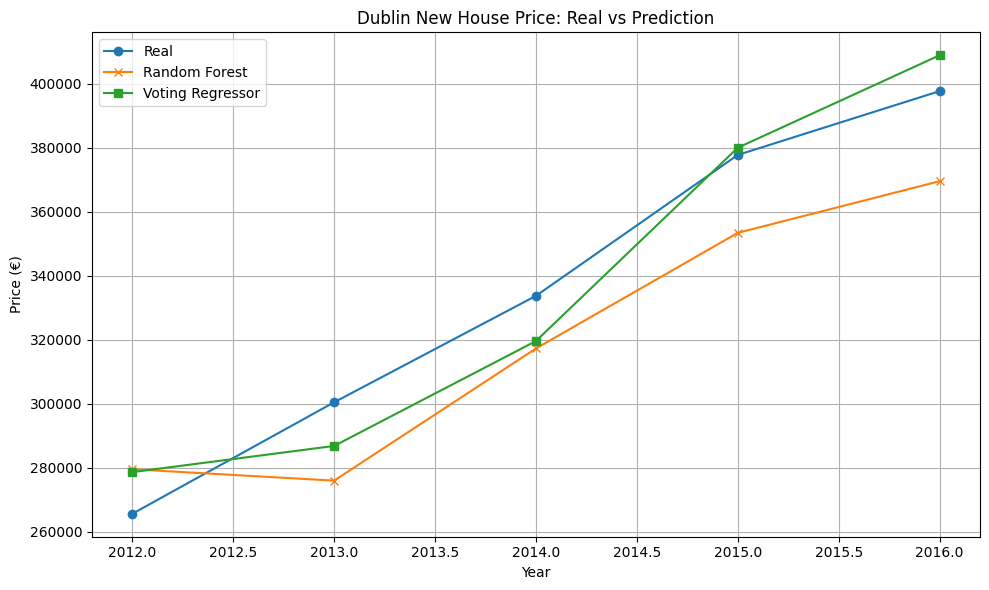

In [20]:
###################################
# Visualisation: Real vs Prediction
###################################
plt.figure(figsize=(10, 6))
plt.plot(model_df["Year"].iloc[-len(y_test):], y_test, label="Real", marker='o')
plt.plot(model_df["Year"].iloc[-len(y_test):], y_pred_rf, label="Random Forest", marker='x')
plt.plot(model_df["Year"].iloc[-len(y_test):], voting_pred, label="Voting Regressor", marker='s')
plt.title("Dublin New House Price: Real vs Prediction")
plt.xlabel("Year")
plt.ylabel("Price (€)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

###########################################################################
# STEP 5: FEATURE (EXTRACTION) ENGINEERING
###########################################################################

In [60]:
###########################################
# FIRST EXTRACTION FOR FEATURE ENGINEERING
###########################################
first_ext_df = model_df.copy()

# Lag Feature
first_ext_df["PriceLag1"] = model_df["DublinNewHousePrice€"].shift(1)
first_ext_df["GDPGrowthLag1"] = model_df["IEGDPGrowthRate"].shift(1)
first_ext_df["InflationLag1"] = model_df["IEInflationRate"].shift(1)

# Price Change Rate
first_ext_df["PriceChangeRate"] = model_df["DublinNewHousePrice€"].pct_change()

# The Rates
first_ext_df["ConstructionCostToPrice"] = model_df["NationalHouseConstructionCostIndex100Base1991"] / model_df["DublinNewHousePrice€"]
first_ext_df["UrbanToTotalPop"] = model_df["IEUrbanPopulation"] / model_df["IEPopulation"]
first_ext_df["MigrantToTotalPop"] = model_df["IEMigrantPopulation"] / model_df["IEPopulation"]

# Interaction Features
first_ext_df["GDPInflationInteraction"] = model_df["IEGDPGrowthRate"] * model_df["IEInflationRate"]
first_ext_df["UnemploymentToGDP"] = model_df["IEUnemploymentRate"] * model_df["IEGDPPerCapita$"]

first_ext_df

,Year,NationalHouseConstructionCostIndex100Base1991,NationalHouseConstructionCostIndexIncreaseonPreviousYearRate,DublinNewHousePrice€,NationalNewHousePrice€,IEPopulation,DublinPopulation,IEUrbanPopulation,IEMigrantPopulation,IEInflationRate,IEInflationAnnualChangeRate,IEGDP$B,IEGDPPerCapita$,IEGDPGrowthRate,IEUnemploymentRate,IEUnemploymentRateAnnualChangeRate,IERefugeesGrantedAsylum,IERefugeesGrantedAsylumAnnualChangeRate,PriceLag1,GDPGrowthLag1,InflationLag1,PriceChangeRate,ConstructionCostToPrice,UrbanToTotalPop,MigrantToTotalPop,GDPInflationInteraction,UnemploymentToGDP
0,1994,111.000,0.034,81993,72732,3559398,939000,2072766,227427.000,0.023,0.008,57.100,15903,0.058,0.146,-0.010,400.000,2.361,NaN,NaN,NaN,NaN,0.001,0.582,0.064,0.001,2317.067
1,1995,114.700,0.033,86671,77994,3579482,946000,2091287,226892.000,0.025,0.002,69.140,19158,0.096,0.120,-0.026,400.000,0.000,81993.000,0.058,0.023,0.057,0.001,0.584,0.063,0.002,2295.128
2,1996,116.300,0.014,97058,87202,3606728,954000,2116049,288722.000,0.018,-0.008,75.790,20836,0.074,0.117,-0.003,69.000,-0.828,86671.000,0.096,0.025,0.120,0.001,0.587,0.080,0.001,2441.979
3,1997,120.400,0.035,122036,102222,3640150,963000,2146414,288722.000,0.015,-0.002,82.860,22551,0.110,0.102,-0.015,430.000,5.232,97058.000,0.074,0.018,0.257,0.001,0.590,0.079,0.002,2300.202
4,1998,124.900,0.037,160699,125302,3678667,971000,2178016,288722.000,0.024,0.009,90.200,24295,0.088,0.077,-0.025,600.000,0.395,122036.000,0.110,0.015,0.317,0.001,0.592,0.078,0.002,1870.715
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18,2012,203.500,0.002,265633,220415,4564550,1126000,2849043,738401.000,0.017,-0.009,225.630,49055,-0.000,0.154,0.001,6309.000,-0.234,290668.000,0.008,0.026,-0.086,0.001,0.624,0.162,-0.000,7578.997
19,2013,204.700,0.006,300466,228216,4588832,1138000,2873286,738401.000,0.005,-0.012,238.340,51546,0.011,0.137,-0.017,5991.000,-0.050,265633.000,-0.000,0.017,0.131,0.001,0.626,0.161,0.000,7077.266
20,2014,206.000,0.006,333720,246378,4622167,1150000,2903635,738401.000,0.002,-0.003,259.170,55643,0.086,0.119,-0.019,5832.000,-0.026,300466.000,0.011,0.005,0.111,0.001,0.628,0.160,0.000,6599.260
21,2015,207.100,0.005,377741,281432,4665760,1163000,2940510,746260.000,-0.003,-0.005,291.780,62054,0.244,0.099,-0.019,6108.000,0.047,333720.000,0.086,0.002,0.132,0.001,0.630,0.160,-0.001,6149.551


In [61]:
#############################################################
# Filling according to time series with interpolation method
first_ext_df.sort_values("Year", inplace=True)
first_ext_df.interpolate(method='linear', inplace=True)
#############################################################
# Fill forward with previous value
first_ext_df.fillna(method='ffill', inplace=True)
#############################################################
# Fill backward with previous value
first_ext_df.fillna(method='bfill', inplace=True)
#############################################################
# Check out the missing values
first_ext_df.isnull().sum().sum()
#############################################################

0

In [62]:
###########################
# Retrieve data after 1994.
# first_ext_df = df[df["Year"] >= 1994].reset_index(drop=True)

###################################################
# Target variable (Y) and Independent variables (X)
target = "DublinNewHousePrice€"
# Year is not included because the goal is not to introduce time effects directly into the model.
features = first_ext_df.drop(columns=["Year", target])
X = features
y = first_ext_df[target]

####################################
# Split into train and test datasets
####################################
from sklearn.model_selection import train_test_split

# Since it is a time series, shuffle=False
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2) 

##########################
# MACHINE LEARNING MODELS
#########################
# Random Forest
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Linear Regression
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_linear = lin_reg.predict(X_test)

# Lasso Regression
from sklearn.linear_model import Lasso
lasso = Lasso()
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

# Ridge Regression
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

# Support Vector Regressor
from sklearn.svm import SVR
svr = SVR(kernel='rbf', C=100, epsilon=0.1)
svr.fit(X_train, y_train)
y_pred_svr = svr.predict(X_test)

# Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)

# XGBoost Regressor
from xgboost import XGBRegressor
xgb = XGBRegressor(random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

# Voting Regressor
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.linear_model import Ridge
rf_model = RandomForestRegressor(random_state=42)
ridge_model = Ridge()
voting_regressor = VotingRegressor([('xgb', xgb), ('rf', rf_model), ('ridge', ridge_model)])
voting_regressor.fit(X_train, y_train)
voting_pred = voting_regressor.predict(X_test)


################################
# Calculate Performance Metrics
################################
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)}

#
rf_scores = evaluate(y_test, y_pred_rf)
print("rf_scores:", rf_scores)
#
linear_scores = evaluate(y_test, y_pred_linear)
print("linear_scores:", linear_scores)
#
lasso_scores = evaluate(y_test, y_pred_lasso)
print("lasso_scores:", lasso_scores)
#
ridge_scores = evaluate(y_test, y_pred_ridge)
print("ridge_scores:", ridge_scores)
#
svr_scores = evaluate(y_test, y_pred_svr)
print("svr_scores:", svr_scores)
#
gbr_scores = evaluate(y_test, y_pred_gbr)
print("gbr_scores:", gbr_scores)
#
xgb_scores = evaluate(y_test, y_pred_xgb)
print("xgb_scores:", xgb_scores)
#
voting_scores = evaluate(y_test, voting_pred)
print("voting_scores:", voting_scores)

rf_scores: {'MAE': 19516.01399999999, 'RMSE': 20532.026116429417, 'R2': 0.820780010656192}
linear_scores: {'MAE': 27663.91955784289, 'RMSE': 39374.16961208976, 'R2': 0.3409085972547261}
lasso_scores: {'MAE': 44301.52850685204, 'RMSE': 47085.06429868495, 'R2': 0.057483055201421496}
ridge_scores: {'MAE': 24238.814038926223, 'RMSE': 31085.0867915594, 'R2': 0.5892032493518501}
svr_scores: {'MAE': 81147.58742733792, 'RMSE': 94534.37333661185, 'R2': -2.799289001647324}
gbr_scores: {'MAE': 17009.849624557984, 'RMSE': 18519.394121423466, 'R2': 0.8541936696976697}
xgb_scores: {'MAE': 18600.99375, 'RMSE': 22508.34949828428, 'R2': 0.7846176400464343}
voting_scores: {'MAE': 14087.54899528725, 'RMSE': 16413.75780993349, 'R2': 0.885464827796035}


In [63]:
###########################
# Retrieve data after 1994.
# first_ext_df = df[df["Year"] >= 1994].reset_index(drop=True)

###################################################
# Target variable (Y) and Independent variables (X)
target = "DublinNewHousePrice€"
# Year is not included because the goal is not to introduce time effects directly into the model.
features = first_ext_df.drop(columns=["Year", target])
X = features
y = first_ext_df[target]

####################################
# Split into train and test datasets
####################################
from sklearn.model_selection import train_test_split

# Since it is a time series, shuffle=False
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2) 

##########################
# MACHINE LEARNING MODELS
#########################
# Random Forest
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)

# XGBoost Regressor
from xgboost import XGBRegressor
xgb = XGBRegressor(random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

# RandomizedSearchCV on XGBoost
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
xgb_model = XGBRegressor(random_state=42, verbosity=0)
param_dist = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'subsample': [0.7, 0.8, 1.0]       }
random_search = RandomizedSearchCV(xgb_model, param_distributions=param_dist, n_iter=10, scoring='neg_mean_absolute_error', cv=3, random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)
best_xgb = random_search.best_estimator_
best_xgb_pred = best_xgb.predict(X_test)

# Voting Regressor
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.linear_model import Ridge
best_xgb = random_search.best_estimator_
rf_model = RandomForestRegressor(random_state=42)
ridge_model = Ridge()
voting_regressor = VotingRegressor([('xgb', best_xgb), ('rf', rf_model), ('ridge', ridge_model)])
voting_regressor.fit(X_train, y_train)
voting_pred = voting_regressor.predict(X_test)


################################
# Calculate Performance Metrics
################################
def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)}

#
rf_scores = evaluate(y_test, y_pred_rf)
print("rf_scores:", rf_scores)
#
gbr_scores = evaluate(y_test, y_pred_gbr)
print("gbr_scores:", gbr_scores)
#
xgb_scores = evaluate(y_test, y_pred_xgb)
print("xgb_scores:", xgb_scores)
#
best_xgb_scores = evaluate(y_test, best_xgb_pred)
print("best_xgb_scores:", best_xgb_scores)
#
voting_scores = evaluate(y_test, voting_pred)
print("voting_scores:", voting_scores)

rf_scores: {'MAE': 19516.01399999999, 'RMSE': 20532.026116429417, 'R2': 0.820780010656192}
gbr_scores: {'MAE': 17009.849624557984, 'RMSE': 18519.394121423466, 'R2': 0.8541936696976697}
xgb_scores: {'MAE': 18600.99375, 'RMSE': 22508.34949828428, 'R2': 0.7846176400464343}
best_xgb_scores: {'MAE': 22787.86875, 'RMSE': 25551.574661316896, 'R2': 0.7224391747409098}
voting_scores: {'MAE': 11555.998995287251, 'RMSE': 14968.371741603381, 'R2': 0.9047484718479313}


In [64]:
############################################
# SECOND EXTRACTION FOR FEATURE ENGINEERING
############################################
second_ext_df = model_df.copy()

# Lag variables are added to model the effect of past values.
second_ext_df["PriceLag1"] = second_ext_df["DublinNewHousePrice€"].shift(1)
second_ext_df["GDPGrowthLag1"] = second_ext_df["IEGDPGrowthRate"].shift(1)
second_ext_df["InflationLag1"] = second_ext_df["IEInflationRate"].shift(1)

# Annual growth rate inference: Annual rates of change are calculated for certain variables.
second_ext_df["PopulationGrowth"] = second_ext_df["IEPopulation"].pct_change()
second_ext_df["DublinPopulationGrowth"] = second_ext_df["DublinPopulation"].pct_change()
second_ext_df["GDPGrowth"] = second_ext_df["IEGDP$B"].pct_change()
second_ext_df["RefugeeGrowth"] = second_ext_df["IERefugeesGrantedAsylum"].pct_change()

# The difference is taken for the relationship between the construction cost increase rate and inflation.
second_ext_df["RealConstructionCostChange"] = (second_ext_df["NationalHouseConstructionCostIndexIncreaseonPreviousYearRate"] - second_ext_df["IEInflationRate"])

# Urban ratio: The ratio of urban population to total population.
second_ext_df["UrbanizationRate"] = second_ext_df["IEUrbanPopulation"] / second_ext_df["IEPopulation"]

# GDP per capita growth rate: To show how income is changing on a per capita basis.
second_ext_df["GDPPerCapitaGrowth"] = second_ext_df["IEGDPPerCapita$"].pct_change()

# Unemployment Change: It calculates how much the unemployment rate has increased or decreased each year compared to the previous year.
second_ext_df["UnemploymentChange"] = second_ext_df["IEUnemploymentRate"].diff()

second_ext_df

,Year,NationalHouseConstructionCostIndex100Base1991,NationalHouseConstructionCostIndexIncreaseonPreviousYearRate,DublinNewHousePrice€,NationalNewHousePrice€,IEPopulation,DublinPopulation,IEUrbanPopulation,IEMigrantPopulation,IEInflationRate,IEInflationAnnualChangeRate,IEGDP$B,IEGDPPerCapita$,IEGDPGrowthRate,IEUnemploymentRate,IEUnemploymentRateAnnualChangeRate,IERefugeesGrantedAsylum,IERefugeesGrantedAsylumAnnualChangeRate,PriceLag1,GDPGrowthLag1,InflationLag1,PopulationGrowth,DublinPopulationGrowth,GDPGrowth,RefugeeGrowth,RealConstructionCostChange,UrbanizationRate,GDPPerCapitaGrowth,UnemploymentChange
0,1994,111.000,0.034,81993,72732,3559398,939000,2072766,227427.000,0.023,0.008,57.100,15903,0.058,0.146,-0.010,400.000,2.361,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.011,0.582,NaN,NaN
1,1995,114.700,0.033,86671,77994,3579482,946000,2091287,226892.000,0.025,0.002,69.140,19158,0.096,0.120,-0.026,400.000,0.000,81993.000,0.058,0.023,0.006,0.007,0.211,0.000,0.008,0.584,0.205,-0.026
2,1996,116.300,0.014,97058,87202,3606728,954000,2116049,288722.000,0.018,-0.008,75.790,20836,0.074,0.117,-0.003,69.000,-0.828,86671.000,0.096,0.025,0.008,0.008,0.096,-0.828,-0.004,0.587,0.088,-0.003
3,1997,120.400,0.035,122036,102222,3640150,963000,2146414,288722.000,0.015,-0.002,82.860,22551,0.110,0.102,-0.015,430.000,5.232,97058.000,0.074,0.018,0.009,0.009,0.093,5.232,0.020,0.590,0.082,-0.015
4,1998,124.900,0.037,160699,125302,3678667,971000,2178016,288722.000,0.024,0.009,90.200,24295,0.088,0.077,-0.025,600.000,0.395,122036.000,0.110,0.015,0.011,0.008,0.089,0.395,0.013,0.592,0.077,-0.025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18,2012,203.500,0.002,265633,220415,4564550,1126000,2849043,738401.000,0.017,-0.009,225.630,49055,-0.000,0.154,0.001,6309.000,-0.234,290668.000,0.008,0.026,0.004,0.012,-0.056,-0.234,-0.015,0.624,-0.060,0.001
19,2013,204.700,0.006,300466,228216,4588832,1138000,2873286,738401.000,0.005,-0.012,238.340,51546,0.011,0.137,-0.017,5991.000,-0.050,265633.000,-0.000,0.017,0.005,0.011,0.056,-0.050,0.001,0.626,0.051,-0.017
20,2014,206.000,0.006,333720,246378,4622167,1150000,2903635,738401.000,0.002,-0.003,259.170,55643,0.086,0.119,-0.019,5832.000,-0.026,300466.000,0.011,0.005,0.007,0.011,0.087,-0.027,0.004,0.628,0.079,-0.019
21,2015,207.100,0.005,377741,281432,4665760,1163000,2940510,746260.000,-0.003,-0.005,291.780,62054,0.244,0.099,-0.019,6108.000,0.047,333720.000,0.086,0.002,0.009,0.011,0.126,0.047,0.008,0.630,0.115,-0.020


In [65]:
#############################################################
# Filling according to time series with interpolation method
second_ext_df.sort_values("Year", inplace=True)
second_ext_df.interpolate(method='linear', inplace=True)
#############################################################
# Fill forward with previous value
second_ext_df.fillna(method='ffill', inplace=True)
#############################################################
# Fill backward with previous value
second_ext_df.fillna(method='bfill', inplace=True)
#############################################################
# Check out the missing values
second_ext_df.isnull().sum().sum()
#############################################################

0

In [66]:
###########################
# Retrieve data after 1994.
# second_ext_df = df[df["Year"] >= 1994].reset_index(drop=True)

###################################################
# Target variable (Y) and Independent variables (X)
target = "DublinNewHousePrice€"
# Year is not included because the goal is not to introduce time effects directly into the model.
features = second_ext_df.drop(columns=["Year", target])
X = features
y = second_ext_df[target]

####################################
# Split into train and test datasets
####################################
from sklearn.model_selection import train_test_split

# Since it is a time series, shuffle=False
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2) 

##########################
# MACHINE LEARNING MODELS
#########################
# Random Forest
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Linear Regression
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_linear = lin_reg.predict(X_test)

# Lasso Regression
from sklearn.linear_model import Lasso
lasso = Lasso()
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

# Ridge Regression
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

# Support Vector Regressor
from sklearn.svm import SVR
svr = SVR(kernel='rbf', C=100, epsilon=0.1)
svr.fit(X_train, y_train)
y_pred_svr = svr.predict(X_test)

# Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)

# XGBoost Regressor
from xgboost import XGBRegressor
xgb = XGBRegressor(random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

# Voting Regressor
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.linear_model import Ridge
rf_model = RandomForestRegressor(random_state=42)
ridge_model = Ridge()
voting_regressor = VotingRegressor([('xgb', xgb), ('rf', rf_model), ('ridge', ridge_model)])
voting_regressor.fit(X_train, y_train)
voting_pred = voting_regressor.predict(X_test)


################################
# Calculate Performance Metrics
################################
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)}

#
rf_scores = evaluate(y_test, y_pred_rf)
print("rf_scores:", rf_scores)
#
linear_scores = evaluate(y_test, y_pred_linear)
print("linear_scores:", linear_scores)
#
lasso_scores = evaluate(y_test, y_pred_lasso)
print("lasso_scores:", lasso_scores)
#
ridge_scores = evaluate(y_test, y_pred_ridge)
print("ridge_scores:", ridge_scores)
#
svr_scores = evaluate(y_test, y_pred_svr)
print("svr_scores:", svr_scores)
#
gbr_scores = evaluate(y_test, y_pred_gbr)
print("gbr_scores:", gbr_scores)
#
xgb_scores = evaluate(y_test, y_pred_xgb)
print("xgb_scores:", xgb_scores)
#
voting_scores = evaluate(y_test, voting_pred)
print("voting_scores:", voting_scores)

rf_scores: {'MAE': 43625.490000000005, 'RMSE': 48192.68847923407, 'R2': 0.012618148935421902}
linear_scores: {'MAE': 75092.22349576504, 'RMSE': 96185.94373284873, 'R2': -2.9332001952005187}
lasso_scores: {'MAE': 27771.78286109413, 'RMSE': 36326.962462921125, 'R2': 0.43897656689681386}
ridge_scores: {'MAE': 40082.96705532796, 'RMSE': 58265.71442070655, 'R2': -0.4432746476587346}
svr_scores: {'MAE': 81147.87789620967, 'RMSE': 94534.64111331556, 'R2': -2.799310525300367}
gbr_scores: {'MAE': 36970.52596274082, 'RMSE': 42790.97176851622, 'R2': 0.22155644071949943}
xgb_scores: {'MAE': 27308.825, 'RMSE': 31055.808360967276, 'R2': 0.5899767276443058}
voting_scores: {'MAE': 15792.777427936777, 'RMSE': 16161.044620333732, 'R2': 0.8889645416015387}


In [67]:
###########################
# Retrieve data after 1994.
# second_ext_df = df[df["Year"] >= 1994].reset_index(drop=True)

###################################################
# Target variable (Y) and Independent variables (X)
target = "DublinNewHousePrice€"
# Year is not included because the goal is not to introduce time effects directly into the model.
features = second_ext_df.drop(columns=["Year", target])
X = features
y = second_ext_df[target]

####################################
# Split into train and test datasets
####################################
from sklearn.model_selection import train_test_split

# Since it is a time series, shuffle=False
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2) 

##########################
# MACHINE LEARNING MODELS
#########################
# Random Forest
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)

# XGBoost Regressor
from xgboost import XGBRegressor
xgb = XGBRegressor(random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

# RandomizedSearchCV on XGBoost
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
xgb_model = XGBRegressor(random_state=42, verbosity=0)
param_dist = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'subsample': [0.7, 0.8, 1.0]       }
random_search = RandomizedSearchCV(xgb_model, param_distributions=param_dist, n_iter=10, scoring='neg_mean_absolute_error', cv=3, random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)
best_xgb = random_search.best_estimator_
best_xgb_pred = best_xgb.predict(X_test)

# Voting Regressor
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.linear_model import Ridge
best_xgb = random_search.best_estimator_
rf_model = RandomForestRegressor(random_state=42)
ridge_model = Ridge()
voting_regressor = VotingRegressor([('xgb', best_xgb), ('rf', rf_model), ('ridge', ridge_model)])
voting_regressor.fit(X_train, y_train)
voting_pred = voting_regressor.predict(X_test)


################################
# Calculate Performance Metrics
################################
def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)}

#
rf_scores = evaluate(y_test, y_pred_rf)
print("rf_scores:", rf_scores)
#
gbr_scores = evaluate(y_test, y_pred_gbr)
print("gbr_scores:", gbr_scores)
#
xgb_scores = evaluate(y_test, y_pred_xgb)
print("xgb_scores:", xgb_scores)
#
best_xgb_scores = evaluate(y_test, best_xgb_pred)
print("best_xgb_scores:", best_xgb_scores)
#
voting_scores = evaluate(y_test, voting_pred)
print("voting_scores:", voting_scores)

rf_scores: {'MAE': 43625.490000000005, 'RMSE': 48192.68847923407, 'R2': 0.012618148935421902}
gbr_scores: {'MAE': 36970.52596274082, 'RMSE': 42790.97176851622, 'R2': 0.22155644071949943}
xgb_scores: {'MAE': 27308.825, 'RMSE': 31055.808360967276, 'R2': 0.5899767276443058}
best_xgb_scores: {'MAE': 29156.28125, 'RMSE': 32263.167182608246, 'R2': 0.5574760010351311}
voting_scores: {'MAE': 13888.133677936776, 'RMSE': 14666.470693464433, 'R2': 0.9085520301221065}
